# Concurrent Model Comparison

Compare latency between two models by sending requests **simultaneously** using async I/O.

Unlike the sequential `model_comparison.ipynb`, this notebook fires requests to both models at the
same wall-clock instant via `asyncio.gather()`. This reveals real-world behavior when both models
compete for resources — critical for Pay-Go vs PTU and Priority Processing comparisons.

**Latency metrics:** TTFT, Total Time, Tokens/sec (e2e & decode)  
**Quality evaluation:** LLM-as-judge (optional)  
**API support:** Chat Completions API or OpenAI Responses API

## 1. Setup

In [1]:
import sys
sys.path.insert(0, "..")

import os
import asyncio
import nest_asyncio
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from dotenv import load_dotenv

# Async clients
from utils import get_async_openai_client, async_measure_latency, async_measure_responses_latency

# Sync judge (judge calls are lightweight; no need for async)
from utils import get_openai_client, judge_comparison, judge_responses_comparison

# Allow nested event loops in Jupyter
nest_asyncio.apply()

load_dotenv()

True

## 2. Configure API Type & Models

Choose which API to use:
- **`"responses"`** — OpenAI Responses API (recommended for OpenAI models)
- **`"chat_completions"`** — Chat Completions API

Reads model names from `.env` by default. Override inline to test different combinations.

In [2]:
# Choose API type: "responses" or "chat_completions"
API_TYPE = "responses"

async_client = get_async_openai_client()
sync_client = get_openai_client()  # for judge only

if API_TYPE == "responses":
    _measure = async_measure_responses_latency
    _judge = judge_responses_comparison
else:
    _measure = async_measure_latency
    _judge = judge_comparison

MODEL_A = os.getenv("AZURE_MODEL_A", "gpt-5.2")
MODEL_B = os.getenv("AZURE_MODEL_B", "gpt-5.4-mini")
JUDGE_MODEL = os.getenv("AZURE_JUDGE_MODEL", "gpt-5.2")

# --- Experiment knobs ---
NUM_ITERATIONS = 3       # Repeat each prompt N times for statistical power
WARMUP = 1               # Throwaway requests before measured runs
REASONING_EFFORT = None  # "low" | "medium" | "high" | None
MAX_OUTPUT_TOKENS = 256  # Cap output length (None = unlimited)

print(f"API:               {API_TYPE}")
print(f"Model A:           {MODEL_A}")
print(f"Model B:           {MODEL_B}")
print(f"Judge:             {JUDGE_MODEL}")
print(f"Iterations:        {NUM_ITERATIONS}")
print(f"Warmup:            {WARMUP}")
print(f"Reasoning effort:  {REASONING_EFFORT}")
print(f"Max output tokens: {MAX_OUTPUT_TOKENS}")

API:               responses
Model A:           gpt-4o-mini
Model B:           gpt-5.4-mini
Judge:             gpt-5.4
Iterations:        3
Warmup:            1
Reasoning effort:  None
Max output tokens: 256


## 3. Define Test Prompts

Both models receive the same prompts. Mix short and long expected outputs for varied measurement.

In [3]:
prompts = [
    "What is the capital of France?",
    "Explain quantum computing in 3 sentences.",
    "Write a Python function that checks if a string is a palindrome.",
    "Summarize the key ideas of machine learning in a short paragraph.",
]

## 4. Run Concurrent Latency Tests

For each iteration × prompt, both models receive the request **simultaneously** via `asyncio.gather()`.
This means latency numbers reflect real contention — both models are actively streaming at the same time.

In [4]:
# Build kwargs for the API calls
_kwargs = {}
if REASONING_EFFORT:
    if API_TYPE == "responses":
        _kwargs["reasoning"] = {"effort": REASONING_EFFORT}
    else:
        _kwargs["reasoning_effort"] = REASONING_EFFORT
if MAX_OUTPUT_TOKENS is not None:
    if API_TYPE == "responses":
        _kwargs["max_output_tokens"] = MAX_OUTPUT_TOKENS
    else:
        _kwargs["max_completion_tokens"] = MAX_OUTPUT_TOKENS

system_prompt = "You are a helpful assistant."

async def run_concurrent_test():
    # Warm-up: sequential async requests to prime connections
    if WARMUP > 0:
        warmup_messages = [
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": prompts[0]},
        ]
        print(f"Warming up ({WARMUP} requests per model)...")
        for _ in range(WARMUP):
            await _measure(async_client, warmup_messages, MODEL_A, **_kwargs)
            await _measure(async_client, warmup_messages, MODEL_B, **_kwargs)

    results_a = []
    results_b = []

    print(f"Running concurrent test: {MODEL_A} vs {MODEL_B} ({NUM_ITERATIONS} iterations × {len(prompts)} prompts)...")
    for iteration in range(NUM_ITERATIONS):
        for i, prompt in enumerate(prompts):
            messages = [
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": prompt},
            ]
            # Fire both models simultaneously
            r_a, r_b = await asyncio.gather(
                _measure(async_client, messages, MODEL_A, **_kwargs),
                _measure(async_client, messages, MODEL_B, **_kwargs),
            )
            r_a.update(model=MODEL_A, prompt_index=i, prompt=prompt[:100], iteration=iteration, reasoning_effort=REASONING_EFFORT)
            r_b.update(model=MODEL_B, prompt_index=i, prompt=prompt[:100], iteration=iteration, reasoning_effort=REASONING_EFFORT)
            results_a.append(r_a)
            results_b.append(r_b)

    print(f"  ✓ {len(results_a)} measurements per model (concurrent)")
    return results_a, results_b

results_a, results_b = asyncio.get_event_loop().run_until_complete(run_concurrent_test())

Warming up (1 requests per model)...
Running concurrent test: gpt-4o-mini vs gpt-5.4-mini (3 iterations × 4 prompts)...
  ✓ 12 measurements per model (concurrent)


## 5. Side-by-Side Latency Comparison

In [5]:
df_a = pd.DataFrame(results_a)
df_b = pd.DataFrame(results_b)
df_all = pd.concat([df_a, df_b], ignore_index=True)

comparison = df_all.pivot_table(
    index="prompt_index",
    columns="model",
    values=["ttft", "total_time", "tokens_per_second", "decode_tokens_per_second", "completion_tokens"],
    aggfunc="mean",
).round(4)
comparison

completion_tokens              decode_tokens_per_second  \
model              gpt-4o-mini gpt-5.4-mini              gpt-4o-mini   
prompt_index                                                           
0                       8.0000      13.0000                  14.5033   
1                      91.3333      98.0000                  91.5667   
2                     241.6667      62.3333                  96.6467   
3                     117.0000      88.6667                  83.7467   

                          tokens_per_second               total_time  \
model        gpt-5.4-mini       gpt-4o-mini gpt-5.4-mini gpt-4o-mini   
prompt_index                                                           
0                 23.7733            8.4900       7.4300      0.9436   
1                 69.1767           64.7433      39.1833      1.4383   
2                 69.0867           83.0700      35.1600      2.9309   
3                 67.7367           58.6600      40.1933      2.1524   

                                 ttft               
model        gpt-5.4-mini gpt-4o-mini gpt-5.4-mini  
prompt_index                                        
0                  1.7913      0.3919       1.2439  
1                  2.4926      0.4139       1.0780  
2                  1.9576      0.4057       1.0112  
3                  2.2295      0.7383       0.9135

In [6]:
summary = df_all.groupby("model").agg(
    avg_ttft=("ttft", "mean"),
    median_ttft=("ttft", "median"),
    p95_ttft=("ttft", lambda x: x.quantile(0.95)),
    std_ttft=("ttft", "std"),
    avg_total_time=("total_time", "mean"),
    median_total_time=("total_time", "median"),
    p95_total_time=("total_time", lambda x: x.quantile(0.95)),
    std_total_time=("total_time", "std"),
    avg_tps_e2e=("tokens_per_second", "mean"),
    avg_tps_decode=("decode_tokens_per_second", "mean"),
    total_tokens=("completion_tokens", "sum"),
    total_reasoning_tokens=("reasoning_tokens", "sum"),
).round(4)

print(f"=== Latency Summary ({NUM_ITERATIONS} iterations, concurrent) ===")
summary

=== Latency Summary (3 iterations, concurrent) ===


,avg_ttft,median_ttft,p95_ttft,std_ttft,avg_total_time,median_total_time,p95_total_time,std_total_time,avg_tps_e2e,avg_tps_decode,total_tokens,total_reasoning_tokens
model,,,,,,,,,,,,
gpt-4o-mini,0.4875,0.4036,0.9066,0.3076,1.8663,1.6568,3.1789,0.8733,53.7408,71.6158,1374,0
gpt-5.4-mini,1.0616,1.0815,1.4137,0.2688,2.1178,2.2036,2.6400,0.4235,30.4917,57.4433,786,0


### Concurrency Verification

Confirm that requests to both models were dispatched at the same wall-clock instant.
The timestamp delta should be near zero (< 0.01s) for each prompt pair.

In [7]:
from datetime import datetime

deltas = []
for a, b in zip(results_a, results_b):
    ts_a = datetime.fromisoformat(a["run_timestamp"])
    ts_b = datetime.fromisoformat(b["run_timestamp"])
    deltas.append(abs((ts_a - ts_b).total_seconds()))

print(f"Timestamp delta (seconds) — max: {max(deltas):.4f}, mean: {sum(deltas)/len(deltas):.4f}")
if max(deltas) < 0.1:
    print("  ✓ Requests were dispatched concurrently")
else:
    print("  ⚠ Some requests may not have been truly concurrent")

Timestamp delta (seconds) — max: 0.0079, mean: 0.0026
  ✓ Requests were dispatched concurrently


## 6. Latency Charts

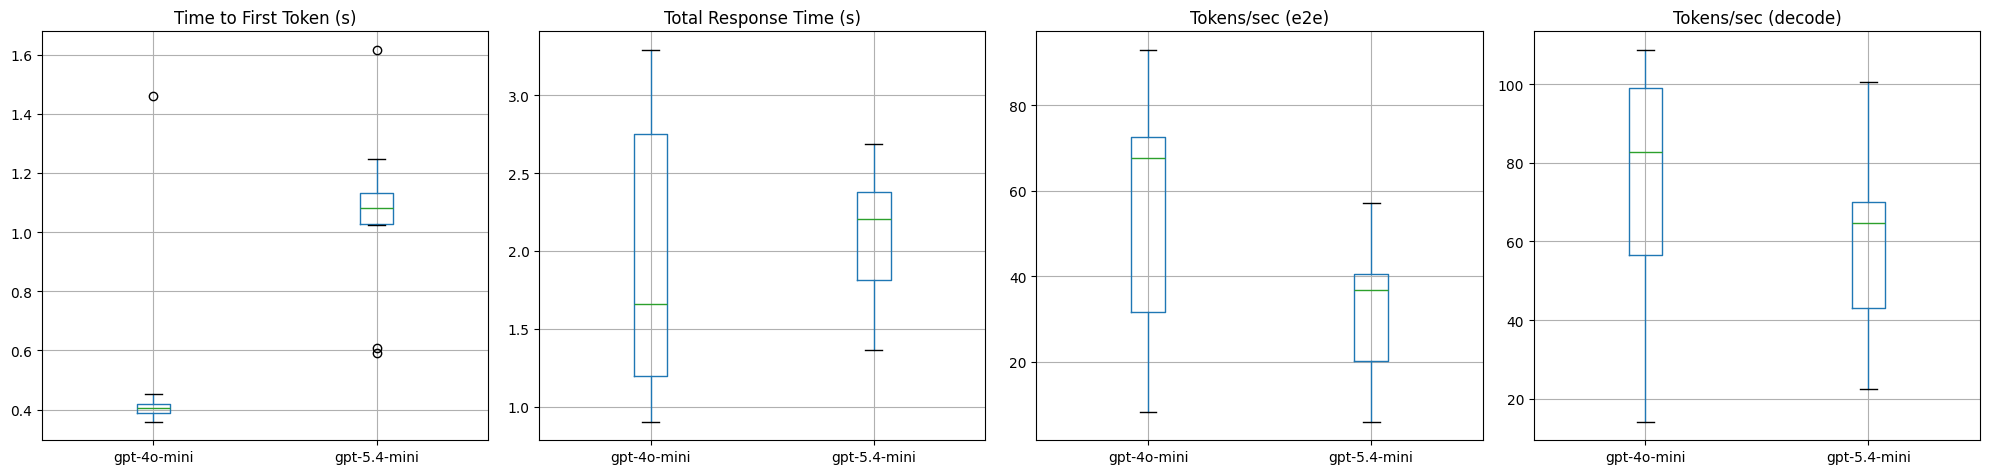

In [8]:
metrics = ["ttft", "total_time", "tokens_per_second", "decode_tokens_per_second"]
titles = ["Time to First Token (s)", "Total Response Time (s)", "Tokens/sec (e2e)", "Tokens/sec (decode)"]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, metric, title in zip(axes, metrics, titles):
    if NUM_ITERATIONS > 1:
        df_all.boxplot(column=metric, by="model", ax=ax)
        ax.set_title(title)
        ax.set_xlabel("")
        plt.suptitle("")
    else:
        pivot = df_all.pivot(index="prompt_index", columns="model", values=metric)
        pivot.plot(kind="bar", ax=ax)
        ax.set_title(title)
        ax.set_xlabel("Prompt")
        ax.legend(title="Model")

plt.tight_layout()
plt.show()

## 7. LLM-as-Judge Quality Evaluation (Optional)

Uses a separate judge model to evaluate response quality on configurable criteria.  
**Skip this section** if you only need latency comparison.

In [ ]:
# Set to True to run the judge evaluation
RUN_JUDGE = True

# Customize criteria as needed
CRITERIA = ["Accuracy", "Completeness", "Clarity"]

In [ ]:
if RUN_JUDGE:
    print(f"Running judge ({JUDGE_MODEL}) via {API_TYPE} API on {len(prompts)} prompt pairs...")
    judgments = _judge(
        client=sync_client,
        judge_model=JUDGE_MODEL,
        prompts=prompts,
        results_a=results_a,
        results_b=results_b,
        model_a_name=MODEL_A,
        model_b_name=MODEL_B,
        criteria=CRITERIA,
    )
    print(f"  ✓ {len(judgments)} evaluations completed")
else:
    print("Judge evaluation skipped. Set RUN_JUDGE = True to enable.")

In [ ]:
if RUN_JUDGE:
    # Build a summary table of judge results
    judge_rows = []
    for j in judgments:
        row = {"prompt": j["prompt"], "winner": j["overall_winner"], "reasoning": j["overall_reasoning"]}
        for ev in j["evaluations"]:
            row[f"{ev['criterion']}_A"] = ev["score_a"]
            row[f"{ev['criterion']}_B"] = ev["score_b"]
        judge_rows.append(row)

    df_judge = pd.DataFrame(judge_rows)
    print(f"=== Quality Evaluation ({MODEL_A} vs {MODEL_B}) ===")
    df_judge

In [ ]:
if RUN_JUDGE:
    wins = df_judge["winner"].value_counts()
    print("=== Win/Loss/Tie Summary ===")
    for outcome, count in wins.items():
        label = MODEL_A if outcome == "A" else MODEL_B if outcome == "B" else "Tie"
        print(f"  {label}: {count}")

## 8. Combined View

Responses side by side for manual inspection.

In [9]:
for i, prompt in enumerate(prompts):
    print(f"\n{'='*80}")
    print(f"Prompt {i}: {prompt}")
    print(f"{'='*80}")
    print(f"\n--- {MODEL_A} (TTFT: {results_a[i]['ttft']}s, Total: {results_a[i]['total_time']}s) ---")
    print(results_a[i]["response_text"][:500])
    print(f"\n--- {MODEL_B} (TTFT: {results_b[i]['ttft']}s, Total: {results_b[i]['total_time']}s) ---")
    print(results_b[i]["response_text"][:500])


Prompt 0: What is the capital of France?

--- gpt-4o-mini (TTFT: 0.3959s, Total: 0.943s) ---
The capital of France is Paris.

--- gpt-5.4-mini (TTFT: 1.6157s, Total: 2.19s) ---
The capital of France is **Paris**.

Prompt 1: Explain quantum computing in 3 sentences.

--- gpt-4o-mini (TTFT: 0.4171s, Total: 1.3305s) ---
Quantum computing harnesses the principles of quantum mechanics to process information in fundamentally different ways than classical computers. Instead of using bits as the smallest units of data, which can be either 0 or 1, quantum computers use qubits that can exist in superpositions of states, allowing for parallelism and more complex computations. This unique capability enables quantum computers to solve certain problems, like factoring large numbers or simulating quantum systems, much more

--- gpt-5.4-mini (TTFT: 1.1129s, Total: 2.4448s) ---
Quantum computing is a type of computing that uses qubits instead of classical bits, allowing information to exist in combina